# MNIST (MLP) — da **train.csv** (fallback su MNIST locale)

- Split train/dev con **dev_size = 1000**
- Architetture: `[784, 64, 10]`, `[784, 128, 64, 10]`
- Learning rate: `0.05`, `0.1`
- Attivazioni: `relu`, `sigmoid`
- Iterazioni: `120`, log ogni `20`
- Training **full-batch** (1 iterazione = 1 aggiornamento su tutto il train set)


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [3]:
input_size  = 784
num_classes = 10

dev_size = 1000  # come basso livello

architectures = [
    [784, 64, 10],        # 1 hidden layer
    [784, 128, 64, 10],   # 2 hidden layer
]
learning_rates = [0.05, 0.1]
activations = ["relu", "sigmoid"]

iterations = 120
log_every  = 20

# Nota: per replicare il full-batch GD della versione NumPy
# useremo DataLoader con batch_size = len(dataset) (1 batch/iter)


## Dataset: usa `train.csv`

In [ ]:
from torchvision import datasets, transforms

class MNISTCSVDataset(Dataset):
    """Atteso formato: colonna 'label' + 784 pixel (0..255)."""
    def __init__(self, csv_path: str):
        df = pd.read_csv(csv_path)
        if "label" not in df.columns:
            raise ValueError("Nel CSV manca la colonna 'label'.")
        self.y = torch.tensor(df["label"].values, dtype=torch.long)
        X = df.drop(columns=["label"]).values.astype(np.float32) / 255.0
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def load_dataset():
    # 1) Preferisci train.csv se esiste
    if os.path.exists("train.csv"):
        print("Trovato train.csv → uso MNIST da CSV.")
        full = MNISTCSVDataset("train.csv")

        # split train/dev con dev_size fisso = 1000
        n_total = len(full)
        n_dev = min(dev_size, n_total)
        n_train = n_total - n_dev

        train_ds, dev_ds = random_split(
            full, [n_train, n_dev],
            generator=torch.Generator().manual_seed(42)
        )
        return train_ds, dev_ds, "csv"

    # 2) Fallback: MNIST locale (NO download). Richiede file in ./data/MNIST/raw
    print("ℹ️ train.csv non trovato. Provo MNIST locale in ./data (download=False).")
    transform = transforms.ToTensor()
    full_train = datasets.MNIST("./data", train=True, transform=transform, download=False)

    # split train/dev sul TRAIN set con dev_size=1000
    n_total = len(full_train)
    n_dev = min(dev_size, n_total)
    n_train = n_total - n_dev

    train_ds, dev_ds = random_split(
        full_train, [n_train, n_dev],
        generator=torch.Generator().manual_seed(42)
    )
    return train_ds, dev_ds, "torchvision"

train_dataset, val_dataset, mode = load_dataset()
print("Mode:", mode)
print("Train size:", len(train_dataset), " Dev size:", len(val_dataset))


✅ Trovato train.csv → uso MNIST da CSV.
Mode: csv
Train size: 41000  Dev size: 1000


## DataLoader + visualizzazione (full-batch)

images: torch.Size([41000, 784])
labels: torch.Size([41000])


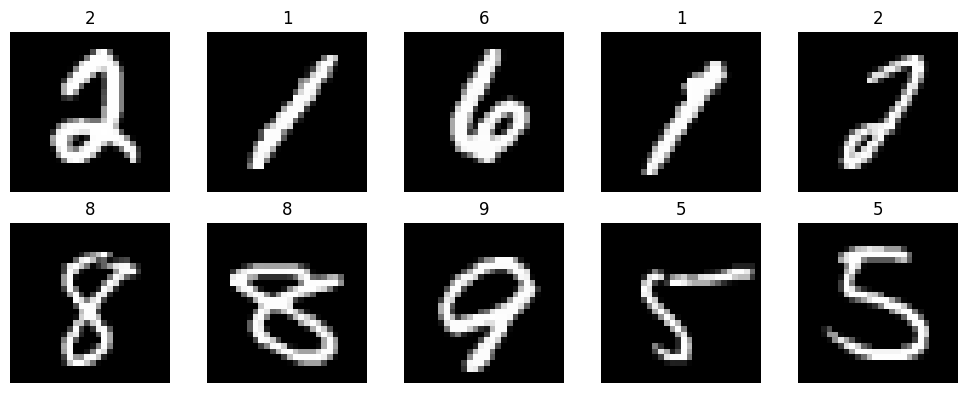

In [5]:
# FULL-BATCH: 1 batch = tutto il dataset (come il NumPy)
train_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=len(val_dataset),   shuffle=False)

images, labels = next(iter(train_loader))
print("images:", images.shape)
print("labels:", labels.shape)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    if mode == "csv":
        img = images[i].reshape(28, 28)
    else:
        img = images[i][0]
    plt.imshow(img, cmap="gray")
    plt.title(int(labels[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()


## Modello MLP

In [ ]:
class MLP(nn.Module):
    """
    layer_sizes es: [784, 64, 10] oppure [784, 128, 64, 10]
    activation: 'relu' oppure 'sigmoid'
    """
    def __init__(self, layer_sizes, activation="relu"):
        super().__init__()
        assert len(layer_sizes) >= 2
        self.activation = activation
        self.layers = nn.ModuleList(
            [nn.Linear(layer_sizes[i], layer_sizes[i+1]) for i in range(len(layer_sizes)-1)]
        )

    def act(self, x):
        if self.activation == "relu":
            return F.relu(x)
        elif self.activation == "sigmoid":
            return torch.sigmoid(x)
        raise ValueError("activation must be 'relu' or 'sigmoid'")

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = self.act(layer(x))
        x = self.layers[-1](x) 
        return x

def num_params(model):
    return sum(p.numel() for p in model.parameters())


## Training + Valutazione

In [7]:
criterion = nn.CrossEntropyLoss()

def accuracy_on_tensors(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def get_full_batch(loader):
    x, y = next(iter(loader))
    if mode == "torchvision":
        x = x.view(x.size(0), -1)
    return x.to(device), y.to(device)

def train_model_torch(train_loader, val_loader, layer_sizes, activation="relu",
                      lr=0.1, iterations=100, log_every=10):
    model = MLP(layer_sizes, activation=activation).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)  # vicino al GD base NumPy

    history = {"iter": [], "train_loss": [], "dev_acc": []}

    X_train, Y_train = get_full_batch(train_loader)
    X_dev,   Y_dev   = get_full_batch(val_loader)

    print("Num params:", num_params(model))

    for i in range(iterations + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(X_train)
        loss = criterion(logits, Y_train)
        loss.backward()
        optimizer.step()

        if i % log_every == 0:
            model.eval()
            with torch.no_grad():
                train_loss = loss.item()
                dev_logits = model(X_dev)
                dev_acc = accuracy_on_tensors(dev_logits, Y_dev)

            history["iter"].append(i)
            history["train_loss"].append(train_loss)
            history["dev_acc"].append(dev_acc)
            print(f"iter={i:4d} | loss={train_loss:.4f} | dev_acc={dev_acc:.4f}")

    return model, history


## Esperimenti

In [8]:
runs = []
for act in activations:
    for arch in architectures:
        for lr in learning_rates:
            print("\n" + "-"*70)
            print(f"activation={act} | arch={arch} | lr={lr}")
            model, hist = train_model_torch(
                train_loader, val_loader,
                layer_sizes=arch, activation=act,
                lr=lr, iterations=iterations, log_every=log_every
            )
            runs.append({"activation": act, "arch": arch, "lr": lr, "model": model, "history": hist})

print("\nRISULTATI FINALI (dev_acc finale):")
for r in sorted(runs, key=lambda x: x["history"]["dev_acc"][-1], reverse=True):
    print(f"{r['history']['dev_acc'][-1]:.4f} | {r['activation']:<7} | {r['arch']} | lr={r['lr']}")



----------------------------------------------------------------------
activation=relu | arch=[784, 64, 10] | lr=0.05
Num params: 50890
iter=   0 | loss=2.3118 | dev_acc=0.0920
iter=  20 | loss=2.1574 | dev_acc=0.4570
iter=  40 | loss=1.9302 | dev_acc=0.6040
iter=  60 | loss=1.6398 | dev_acc=0.7010
iter=  80 | loss=1.3402 | dev_acc=0.7640
iter= 100 | loss=1.0928 | dev_acc=0.8000
iter= 120 | loss=0.9176 | dev_acc=0.8270

----------------------------------------------------------------------
activation=relu | arch=[784, 64, 10] | lr=0.1
Num params: 50890
iter=   0 | loss=2.2952 | dev_acc=0.1930
iter=  20 | loss=1.8086 | dev_acc=0.7250
iter=  40 | loss=1.1910 | dev_acc=0.8040
iter=  60 | loss=0.8452 | dev_acc=0.8460
iter=  80 | loss=0.6793 | dev_acc=0.8660
iter= 100 | loss=0.5863 | dev_acc=0.8800
iter= 120 | loss=0.5270 | dev_acc=0.8860

----------------------------------------------------------------------
activation=relu | arch=[784, 128, 64, 10] | lr=0.05
Num params: 109386
iter=   0 

## Plot convergenza (loss e dev accuracy)

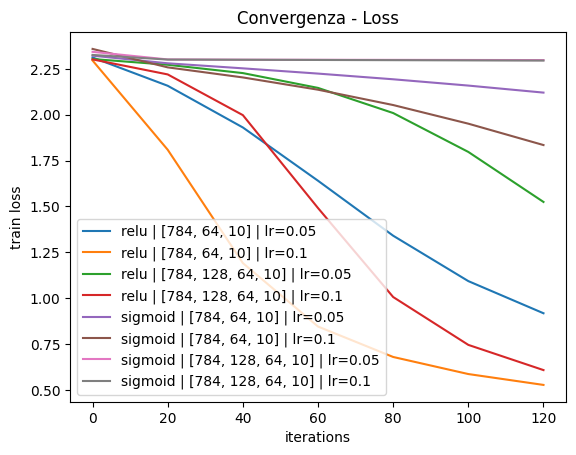

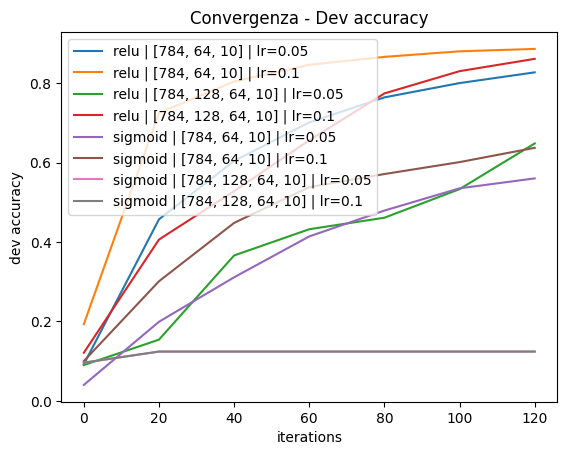

In [9]:
plt.figure()
for r in runs:
    h = r["history"]
    label = f"{r['activation']} | {r['arch']} | lr={r['lr']}"
    plt.plot(h["iter"], h["train_loss"], label=label)
plt.xlabel("iterations")
plt.ylabel("train loss")
plt.title("Convergenza - Loss")
plt.legend()
plt.show()

plt.figure()
for r in runs:
    h = r["history"]
    label = f"{r['activation']} | {r['arch']} | lr={r['lr']}"
    plt.plot(h["iter"], h["dev_acc"], label=label)
plt.xlabel("iterations")
plt.ylabel("dev accuracy")
plt.title("Convergenza - Dev accuracy")
plt.legend()
plt.show()


BEST: relu [784, 64, 10] lr= 0.1 dev_acc= 0.8859999775886536


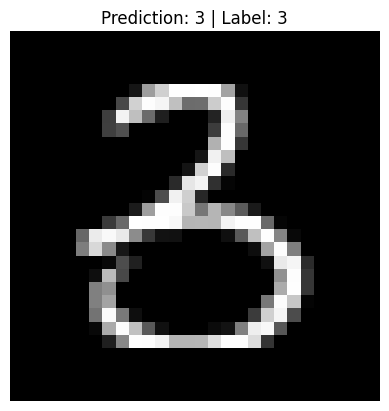

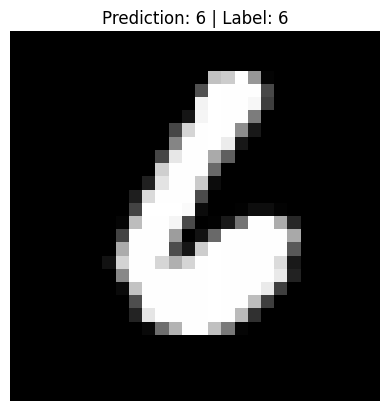

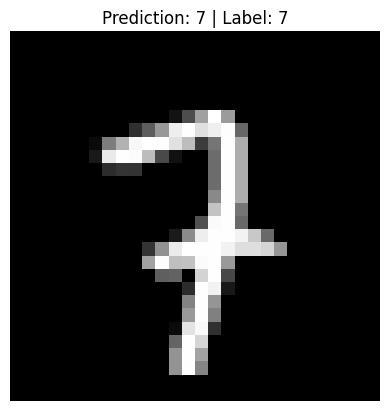

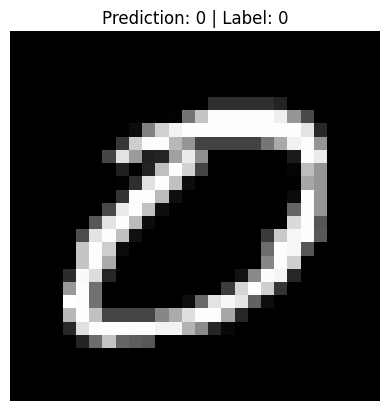

In [10]:
best = max(runs, key=lambda x: x["history"]["dev_acc"][-1])
best_model = best["model"]

print("BEST:", best["activation"], best["arch"], "lr=", best["lr"], "dev_acc=", best["history"]["dev_acc"][-1])

X_train_full, Y_train_full = get_full_batch(train_loader)

def show_prediction(index, model):
    model.eval()
    x = X_train_full[index:index+1]
    y = Y_train_full[index].item()

    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).item()

    img = x.view(28, 28).detach().cpu().numpy() * 255.0
    plt.figure()
    plt.imshow(img, cmap="gray", interpolation="nearest")
    plt.title(f"Prediction: {pred} | Label: {y}")
    plt.axis("off")
    plt.show()

for idx in [0, 1, 2, 3]:
    show_prediction(idx, best_model)
